In [1]:
pip install torch torchvision opencv-python matplotlib ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.2 MB/s eta 0:00:00


In [2]:
pip install kagglehub[pandas-datasets]

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "snehilsanyal/construction-site-safety-image-dataset-roboflow"
)

print("데이터셋 저장 경로:", path)

100%|██████████| 206M/206M [00:02<00:00, 79.3MB/s]

Extracting files...


데이터셋 저장 경로: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3


In [4]:
import os

print(os.listdir(path))

['results_yolov8n_100e', 'css-data', 'source_files']


In [5]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import yaml

# Set the path to the file you'd like to load
yaml_path = os.path.join(
    path, "results_yolov8n_100e", "kaggle", "working", "ppe_data.yaml"
)

# Make new yaml file

base_path = '/root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3'

data_cfg = {
    'path': base_path, # 루트 경로
    'train': 'css-data/train/images', # train 이미지 폴더
    'val': 'css-data/valid/images',   # validation 이미지 폴더
    'test': 'css-data/test/images',   # test 이미지 폴더

    'names': {
        0: 'Hardhat',
        1: 'Mask',
        2: 'NO-Hardhat',
        3: 'NO-Mask',
        4: 'NO-Safety Vest',
        5: 'Person',
        6: 'Safety Cone',
        7: 'Safety Vest',
        8: 'machinery',
        9: 'vehicle'
    }
}

new_yaml_path = 'custom_ppe_data.yaml'
with open(new_yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)



---



# Yolo Version 8 Nano

In [6]:
import os
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=new_yaml_path,
    epochs=50,
    imgsz=800,
    batch=16,
    seed=42,
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_ppe_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torc


0: 544x800 3 Hardhats, 4 NO-Masks, 6 Persons, 3 Safety Vests, 2 machinerys, 9.5ms
Speed: 3.9ms preprocess, 9.5ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 800)


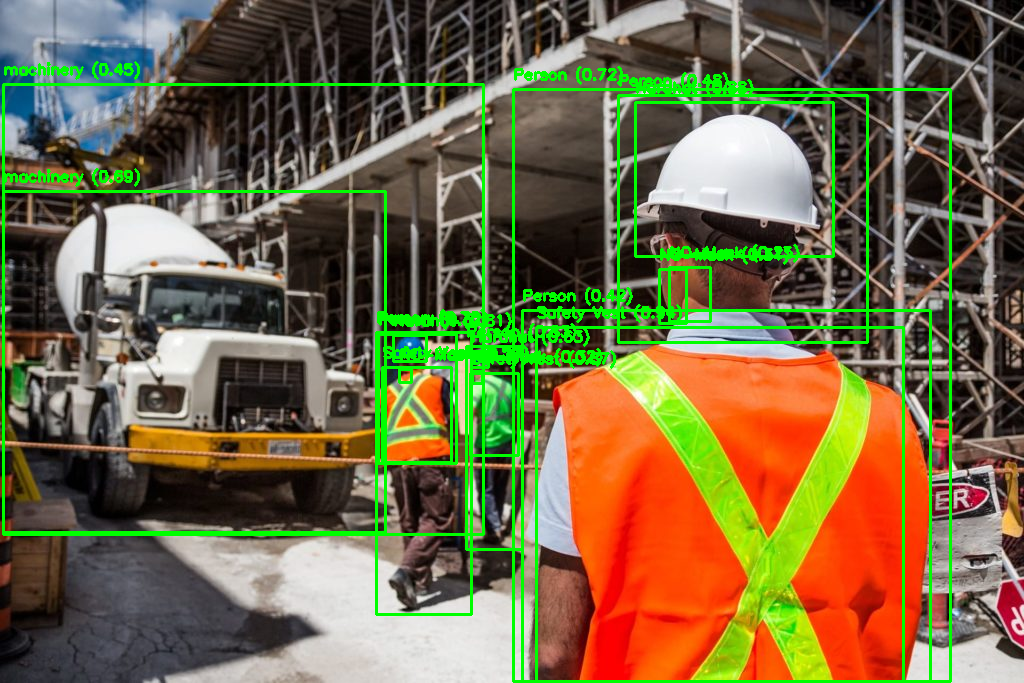

In [7]:
import cv2
from google.colab.patches import cv2_imshow

# 학습된 YOLO 모델 로드
model = YOLO("/content/runs/detect/train/weights/best.pt")

# 테스트할 이미지 불러오기
image_path = "/root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/source_files/source_files/construction-safety.jpg"
image = cv2.imread(image_path)

# 객체 탐지 실행
results = model(image)

# 탐지된 객체 시각화
for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 좌표값 변환
    label = result.names[int(box.cls[0])] # 클래스 라벨
    confidence = box.conf[0] # 신뢰도

    # 객체 경계 상자 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{label} ({confidence:.2f})", (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 결과 출력
cv2_imshow(image)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1861.4±380.7 MB/s, size: 61.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 31.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.7it/s 4.8s
                   all        114        697      0.875      0.744      0.805      0.485
               Hardhat         42         79      0.939      0.747      0.858      0.543
                  Mask         19         21      0.922      0.905      0.934      0.629
            NO-Hardhat         37         69      0.953      0.588      0.687      0.359
               NO-Mask         44         74      0.829      0.595      0.651       0.32
        NO-Safety Vest         56

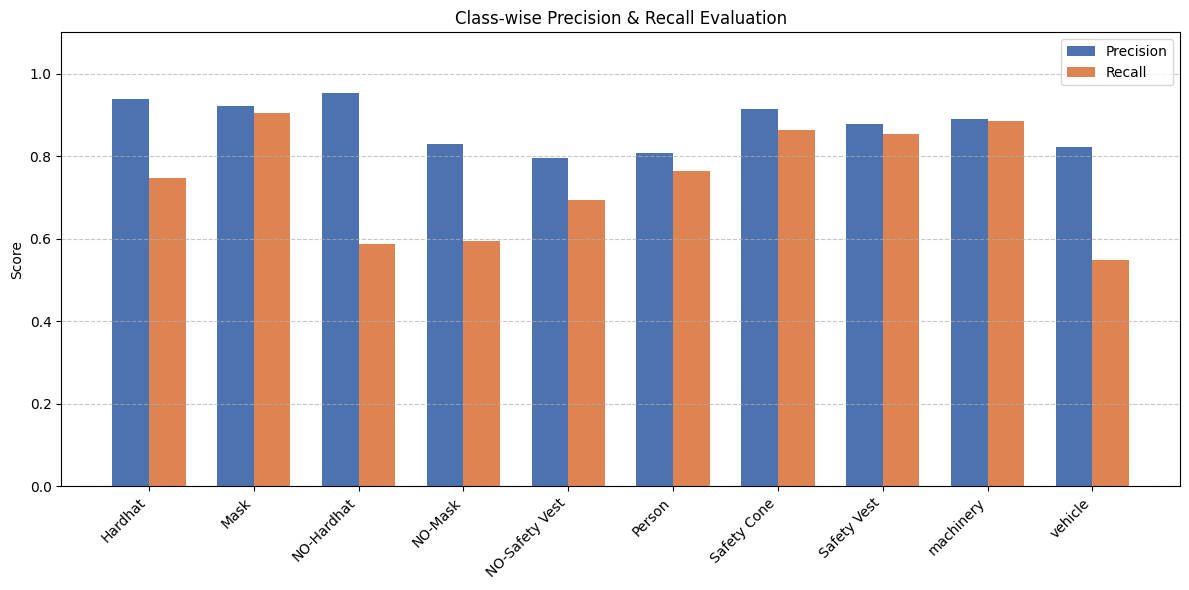

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델 검증 실행
metrics = model.val()

# 2. 클래스 이름 및 지표 추출
class_names = list(metrics.names.values())
precisions = metrics.box.p  # 각 클래스별 Precision (numpy array)
recalls = metrics.box.r  # 각 클래스별 Recall (numpy array)

x = np.arange(len(class_names))
width = 0.35

# 3. 막대그래프 시각화
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, precisions, width, label="Precision", color="#4C72B0")
plt.bar(x + width / 2, recalls, width, label="Recall", color="#DD8452")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Class-wise Precision & Recall Evaluation")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



---



# Yolo Version 8 Nano, Augmentation

In [9]:
model = YOLO('yolov8n.pt')

results = model.train(
    data=new_yaml_path,
    epochs=50,
    imgsz=800,
    batch=16,
    seed=42,

    # --- 기하학적 증강 ---
    degrees=10.0,           # 작업자 몸 기울임 반영
    translate=0.1,          # 위치 이동
    scale=0.25,             # 작은 얼굴/헬멧 픽셀 깨짐 방지
    shear=2.0,              # 왜곡
    perspective=0.0005,     # 원근
    fliplr=0.5,             # 좌우 반전
    flipud=0.0,             # 상하 반전 끔

    # --- 색상 증강 ---
    hsv_h=0.015,            # 색상 변화 최소
    hsv_s=0.4,              # 형광/안전장구 고유 색감 보존
    hsv_v=0.4,              # 그림자/직사광선 조도 반영

    # --- 추가 증강 ---
    close_mosaic=10,        # 마지막 10 epoch은 모자이크를 꺼서 원본 디테일 학습
    erasing=0.2             # 가림/폐색(다른 물체에 살짝 가려진 상태) 학습
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_ppe_data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, 


0: 544x800 3 Hardhats, 3 NO-Masks, 4 Persons, 3 Safety Vests, 1 machinery, 5.7ms
Speed: 4.6ms preprocess, 5.7ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 800)


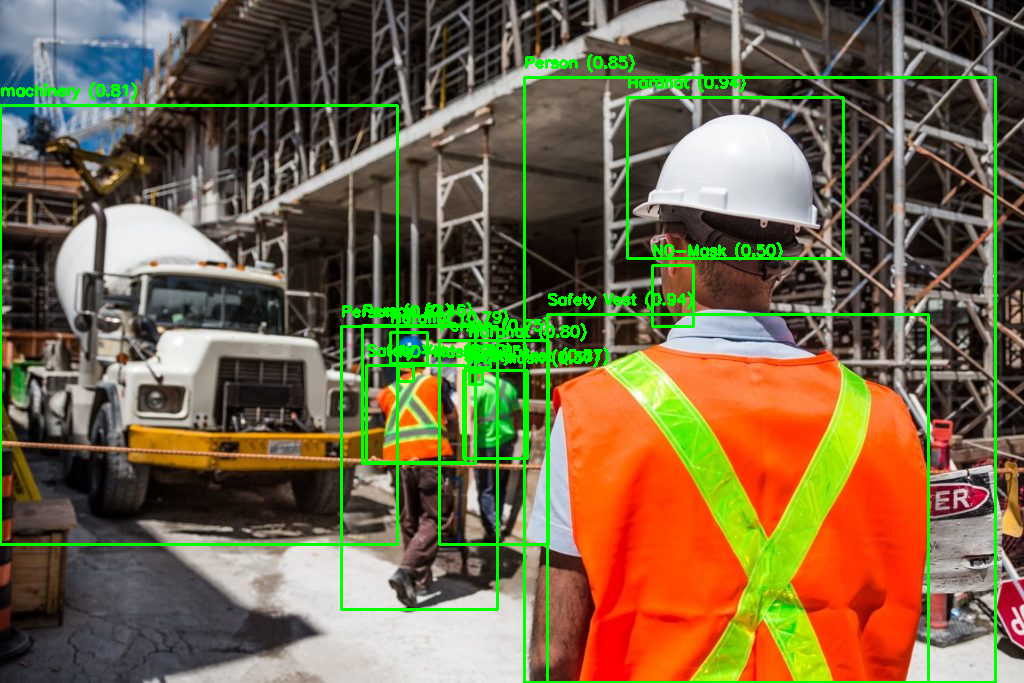

In [10]:
import cv2
from google.colab.patches import cv2_imshow

# 학습된 YOLO 모델 로드
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# 테스트할 이미지 불러오기
image_path = "/root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/source_files/source_files/construction-safety.jpg"
image = cv2.imread(image_path)

# 객체 탐지 실행
results = model(image)

# 탐지된 객체 시각화
for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 좌표값 변환
    label = result.names[int(box.cls[0])] # 클래스 라벨
    confidence = box.conf[0] # 신뢰도

    # 객체 경계 상자 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{label} ({confidence:.2f})", (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 결과 출력
cv2_imshow(image)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1412.3±312.8 MB/s, size: 61.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 31.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.5s
                   all        114        697      0.852      0.752      0.806       0.38
               Hardhat         42         79      0.886      0.785      0.889      0.476
                  Mask         19         21      0.924      0.857      0.929      0.432
            NO-Hardhat         37         69      0.836      0.565      0.671      0.289
               NO-Mask         44         74      0.842      0.649      0.681      0.277
        NO-Safety Vest         56

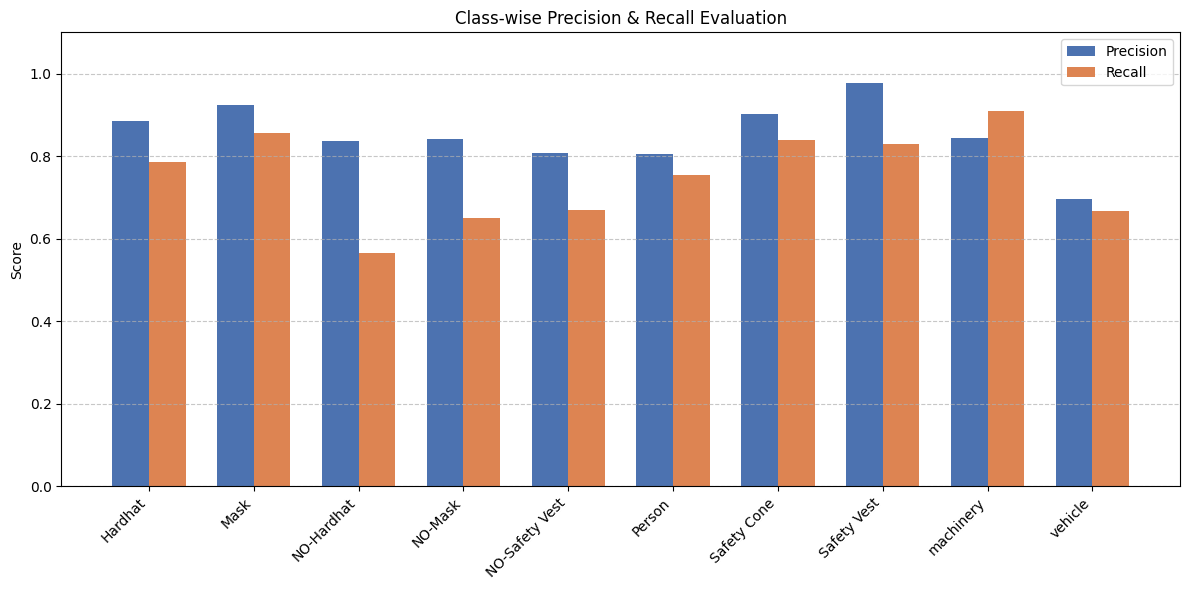

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델 검증 실행
metrics = model.val()

# 2. 클래스 이름 및 지표 추출
class_names = list(metrics.names.values())
precisions = metrics.box.p  # 각 클래스별 Precision (numpy array)
recalls = metrics.box.r  # 각 클래스별 Recall (numpy array)

x = np.arange(len(class_names))
width = 0.35

# 3. 막대그래프 시각화
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, precisions, width, label="Precision", color="#4C72B0")
plt.bar(x + width / 2, recalls, width, label="Recall", color="#DD8452")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Class-wise Precision & Recall Evaluation")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



---



# Yolo Version 8 Small

In [12]:
model = YOLO('yolov8s.pt')

results = model.train(
    data=new_yaml_path,
    epochs=50,
    imgsz=800,
    batch=16,
    seed=42,
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_ppe_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, o


0: 544x800 3 Hardhats, 2 NO-Masks, 6 Persons, 3 Safety Vests, 1 machinery, 8.6ms
Speed: 4.3ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 800)


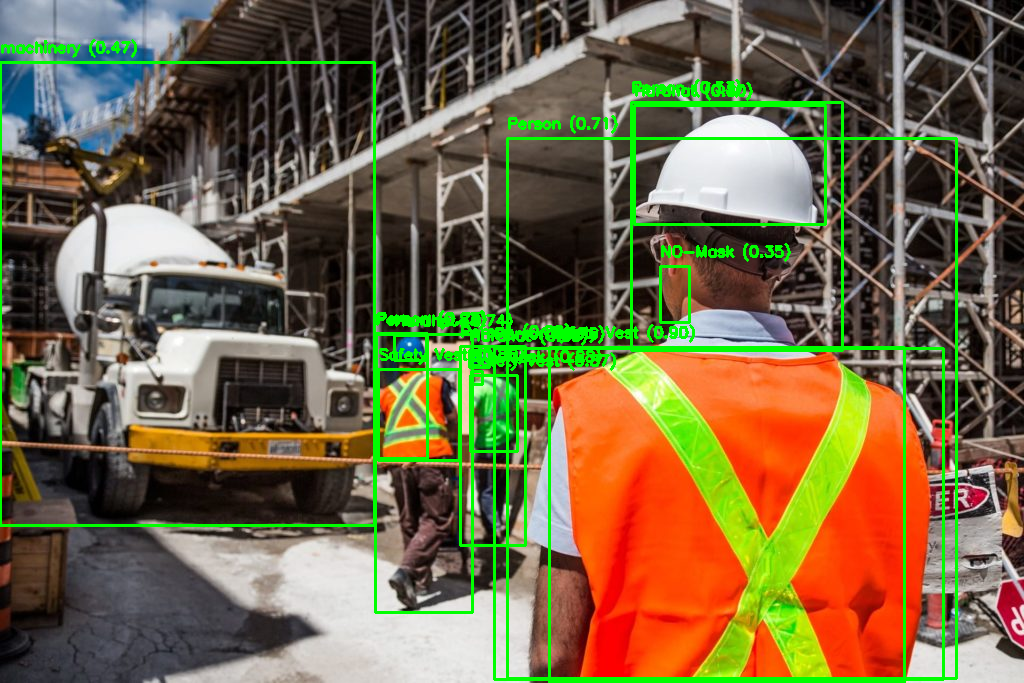

In [13]:
import cv2
from google.colab.patches import cv2_imshow

# 학습된 YOLO 모델 로드
model = YOLO("/content/runs/detect/train-3/weights/best.pt")

# 테스트할 이미지 불러오기
image_path = "/root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/source_files/source_files/construction-safety.jpg"
image = cv2.imread(image_path)

# 객체 탐지 실행
results = model(image)

# 탐지된 객체 시각화
for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 좌표값 변환
    label = result.names[int(box.cls[0])] # 클래스 라벨
    confidence = box.conf[0] # 신뢰도

    # 객체 경계 상자 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{label} ({confidence:.2f})", (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 결과 출력
cv2_imshow(image)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1567.3±467.0 MB/s, size: 61.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 28.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.1s
                   all        114        697      0.902      0.814      0.867      0.566
               Hardhat         42         79      0.902      0.873      0.908      0.613
                  Mask         19         21      0.971      0.952      0.955       0.71
            NO-Hardhat         37         69      0.905      0.694      0.804      0.458
               NO-Mask         44         74       0.82      0.662      0.723      0.429
        NO-Safety Vest         56

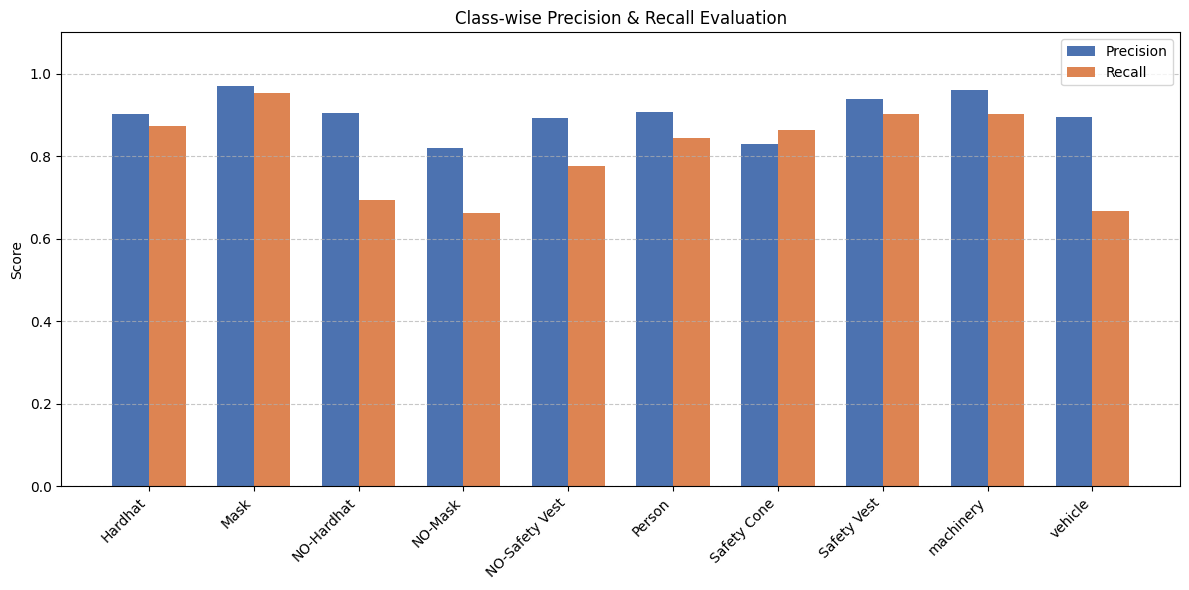

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델 검증 실행
metrics = model.val()

# 2. 클래스 이름 및 지표 추출
class_names = list(metrics.names.values())
precisions = metrics.box.p  # 각 클래스별 Precision (numpy array)
recalls = metrics.box.r  # 각 클래스별 Recall (numpy array)

x = np.arange(len(class_names))
width = 0.35

# 3. 막대그래프 시각화
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, precisions, width, label="Precision", color="#4C72B0")
plt.bar(x + width / 2, recalls, width, label="Recall", color="#DD8452")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Class-wise Precision & Recall Evaluation")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



---



# Yolo Version 8 Small, Augmentation

In [15]:
model = YOLO('yolov8s.pt')

results = model.train(
    data=new_yaml_path,
    epochs=50,
    imgsz=800,
    batch=16,
    seed=42,

    # --- 기하학적 증강 ---
    degrees=10.0,           # 작업자 몸 기울임 반영
    translate=0.1,          # 위치 이동
    scale=0.25,             # 작은 얼굴/헬멧 픽셀 깨짐 방지
    shear=2.0,              # 왜곡
    perspective=0.0005,     # 원근
    fliplr=0.5,             # 좌우 반전
    flipud=0.0,             # 상하 반전 끔

    # --- 색상 증강 ---
    hsv_h=0.015,            # 색상 변화 최소
    hsv_s=0.4,              # 형광/안전장구 고유 색감 보존
    hsv_v=0.4,              # 그림자/직사광선 조도 반영

    # --- 추가 증강 ---
    close_mosaic=10,        # 마지막 10 epoch은 모자이크를 꺼서 원본 디테일 학습
    erasing=0.2             # 가림/폐색(다른 물체에 살짝 가려진 상태) 학습
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_ppe_data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, 


0: 544x800 4 Hardhats, 1 NO-Mask, 5 Persons, 2 Safety Cones, 3 Safety Vests, 2 machinerys, 8.9ms
Speed: 4.3ms preprocess, 8.9ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 800)


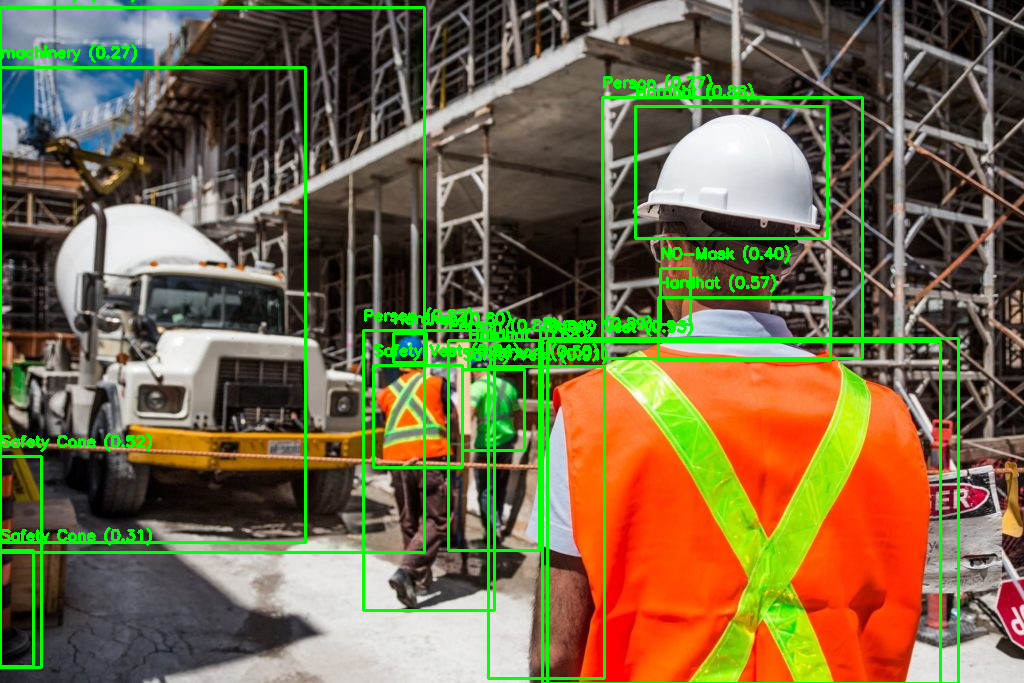

In [16]:
import cv2
from google.colab.patches import cv2_imshow

# 학습된 YOLO 모델 로드
model = YOLO("/content/runs/detect/train-4/weights/best.pt")

# 테스트할 이미지 불러오기
image_path = "/root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/source_files/source_files/construction-safety.jpg"
image = cv2.imread(image_path)

# 객체 탐지 실행
results = model(image)

# 탐지된 객체 시각화
for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 좌표값 변환
    label = result.names[int(box.cls[0])] # 클래스 라벨
    confidence = box.conf[0] # 신뢰도

    # 객체 경계 상자 그리기
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{label} ({confidence:.2f})", (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 결과 출력
cv2_imshow(image)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1568.1±439.2 MB/s, size: 61.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 26.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.7s
                   all        114        697      0.908      0.781      0.845      0.455
               Hardhat         42         79      0.963      0.823      0.886      0.509
                  Mask         19         21          1       0.94      0.955      0.488
            NO-Hardhat         37         69      0.887       0.57      0.726      0.338
               NO-Mask         44         74      0.912      0.649      0.702       0.34
        NO-Safety Vest         56

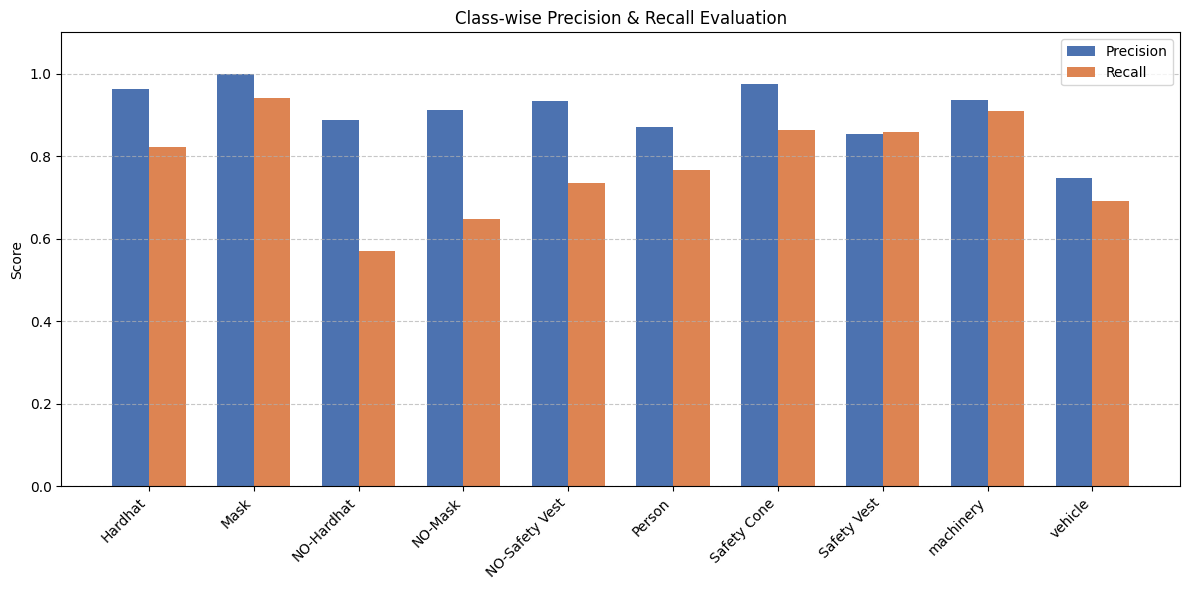

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 모델 검증 실행
metrics = model.val()

# 2. 클래스 이름 및 지표 추출
class_names = list(metrics.names.values())
precisions = metrics.box.p  # 각 클래스별 Precision (numpy array)
recalls = metrics.box.r  # 각 클래스별 Recall (numpy array)

x = np.arange(len(class_names))
width = 0.35

# 3. 막대그래프 시각화
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, precisions, width, label="Precision", color="#4C72B0")
plt.bar(x + width / 2, recalls, width, label="Recall", color="#DD8452")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Class-wise Precision & Recall Evaluation")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()